# OASIS Alzheimer's Classification — SMOTE Experiment

**Goal:** Test whether SMOTE class balancing improves classification performance compared to the baseline (unbalanced) models.

**Feature set used:** This experiment builds on the **biomarker-only** feature set from the baseline notebook (Age, Gender, Educ, SES, MMSE, eTIV, nWBV, ASF) — `CDR` is excluded throughout, since it directly determines the target and would cause label leakage rather than a meaningful test of class balancing. All "original" results referenced below are the Experiment B baseline results, not the leaked Experiment A results.

SMOTE (Synthetic Minority Oversampling Technique) is applied **only to the training set** — the test set must remain untouched and reflect the real-world class distribution, otherwise evaluation metrics would be misleadingly optimistic.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
MODEL_COLORS = {"Logistic Regression": "#2E86AB", "Random Forest": "#E76F51", "XGBoost": "#588157"}


## 1. Load Data and Recreate Baseline Split

In [2]:
DATA_PATH = "oasis_cross-sectional.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

def cdr_to_group(cdr):
    if pd.isna(cdr):
        return "Unknown"
    elif cdr == 0:
        return "Nondemented"
    else:
        return "Demented"

df["Group"] = df["CDR"].apply(cdr_to_group)
df = df[df["Group"] != "Unknown"].reset_index(drop=True)

for col in ["Educ", "SES", "MMSE"]:
    df[col] = df[col].fillna(df[col].median())

df["Gender"] = df["M/F"].map({"M": 0, "F": 1})
df["Target"] = df["Group"].map({"Nondemented": 0, "Demented": 1})

features = ["Age", "Gender", "Educ", "SES", "MMSE", "eTIV", "nWBV", "ASF"]  # CDR excluded -- see note above
X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")
print("\nOriginal training class distribution:")
print(y_train.value_counts())


X_train: (188, 8), X_test: (47, 8)

Original training class distribution:
Target
0    108
1     80
Name: count, dtype: int64


## 2. Apply SMOTE — Training Data Only

In [3]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print(f"Shape: {X_train_scaled.shape}")

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
print(f"Shape: {X_train_smote.shape}")

print("\nTest set (untouched, real-world distribution):")
print(y_test.value_counts())


Before SMOTE:
Target
0    108
1     80
Name: count, dtype: int64
Shape: (188, 8)

After SMOTE:
Target
0    108
1    108
Name: count, dtype: int64
Shape: (216, 8)

Test set (untouched, real-world distribution):
Target
0    27
1    20
Name: count, dtype: int64


## 3. Class Distribution — Before vs. After SMOTE

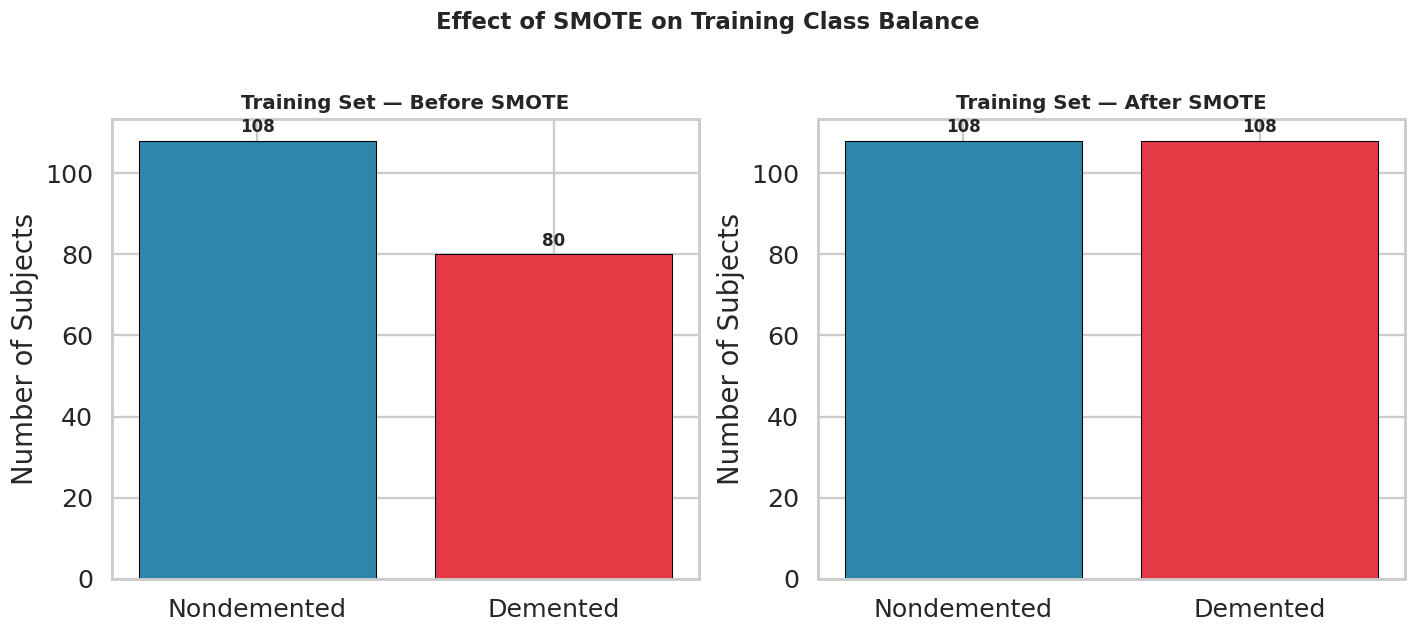

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

before_counts = y_train.value_counts().sort_index()
after_counts = y_train_smote.value_counts().sort_index()
labels = ["Nondemented", "Demented"]
colors = ["#2E86AB", "#E63946"]

axes[0].bar(labels, before_counts.values, color=colors, edgecolor="black", linewidth=0.7)
axes[0].set_title("Training Set — Before SMOTE")
axes[0].set_ylabel("Number of Subjects")
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

axes[1].bar(labels, after_counts.values, color=colors, edgecolor="black", linewidth=0.7)
axes[1].set_title("Training Set — After SMOTE")
axes[1].set_ylabel("Number of Subjects")
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 2, str(v), ha="center", fontweight="bold")

plt.suptitle("Effect of SMOTE on Training Class Balance", y=1.04, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** Before SMOTE, the training set reflects the natural class imbalance seen in the full dataset (more Nondemented than Demented subjects). After SMOTE, both classes are exactly balanced via synthetic minority-class samples generated by interpolating between existing Demented subjects' feature vectors. Critically, the **test set distribution is left untouched**, so evaluation still reflects real-world class proportions.

## 4. Retrain Models on SMOTE-Balanced Data

In [5]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
        "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
    }

def train_and_evaluate(X_train, X_test, y_train, y_test, label=""):
    results = {}
    fitted_models = {}
    for name, model in get_models().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        results[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "y_pred": y_pred,
            "y_proba": y_proba
        }
        fitted_models[name] = model
        print(f"[{label}] {name} trained.")
    return results, fitted_models

print("--- Retraining on SMOTE-balanced training data ---")
results_smote, models_smote = train_and_evaluate(X_train_smote, X_test_scaled, y_train_smote, y_test, label="SMOTE")


--- Retraining on SMOTE-balanced training data ---
[SMOTE] Logistic Regression trained.


[SMOTE] Random Forest trained.
[SMOTE] XGBoost trained.


In [6]:
# Original (non-SMOTE) results, retrained here for a clean side-by-side comparison
print("--- Retraining on original (imbalanced) training data, for comparison ---")
results_orig, models_orig = train_and_evaluate(X_train_scaled, X_test_scaled, y_train, y_test, label="Original")


--- Retraining on original (imbalanced) training data, for comparison ---
[Original] Logistic Regression trained.


[Original] Random Forest trained.
[Original] XGBoost trained.


## 5. Compare Original vs. SMOTE Results

In [7]:
def build_table(results, suffix):
    rows = []
    for name, r in results.items():
        rows.append({
            "Model": name,
            f"Accuracy{suffix}": r["Accuracy"],
            f"Precision{suffix}": r["Precision"],
            f"Recall{suffix}": r["Recall"],
            f"F1{suffix}": r["F1 Score"],
            f"ROC-AUC{suffix}": r["ROC-AUC"]
        })
    return pd.DataFrame(rows).set_index("Model")

table_orig = build_table(results_orig, " (Original)")
table_smote = build_table(results_smote, " (SMOTE)")

comparison = table_orig.join(table_smote).round(3)
# Reorder columns so original/SMOTE pairs sit side by side per metric
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
ordered_cols = [f"{m}{suf}" for m in metrics for suf in [" (Original)", " (SMOTE)"]]
comparison = comparison[ordered_cols]
comparison


,Accuracy (Original),Accuracy (SMOTE),Precision (Original),Precision (SMOTE),Recall (Original),Recall (SMOTE),F1 (Original),F1 (SMOTE),ROC-AUC (Original),ROC-AUC (SMOTE)
Model,,,,,,,,,,
Logistic Regression,0.787,0.809,0.778,0.789,0.70,0.75,0.737,0.769,0.906,0.898
Random Forest,0.830,0.830,0.875,0.833,0.70,0.75,0.778,0.789,0.942,0.928
XGBoost,0.851,0.851,0.882,0.882,0.75,0.75,0.811,0.811,0.941,0.931


In [8]:
# Delta table: SMOTE minus Original, to clearly see improvement/decline per metric
delta = pd.DataFrame(index=comparison.index)
for m in metrics:
    delta[f"Δ {m}"] = (comparison[f"{m} (SMOTE)"] - comparison[f"{m} (Original)"]).round(3)
delta


,Δ Accuracy,Δ Precision,Δ Recall,Δ F1,Δ ROC-AUC
Model,,,,,
Logistic Regression,0.022,0.011,0.05,0.032,-0.008
Random Forest,0.000,-0.042,0.05,0.011,-0.014
XGBoost,0.000,0.000,0.00,0.000,-0.010


**Observation:** Positive Δ values indicate SMOTE improved that metric for that model; negative values indicate it hurt performance. Pay particular attention to **Recall** — since SMOTE specifically targets minority-class (Demented) representation during training, the clearest expected benefit is improved recall on the Demented class, sometimes at a small cost to precision or overall accuracy.

## 6. Confusion Matrices — Original vs. SMOTE

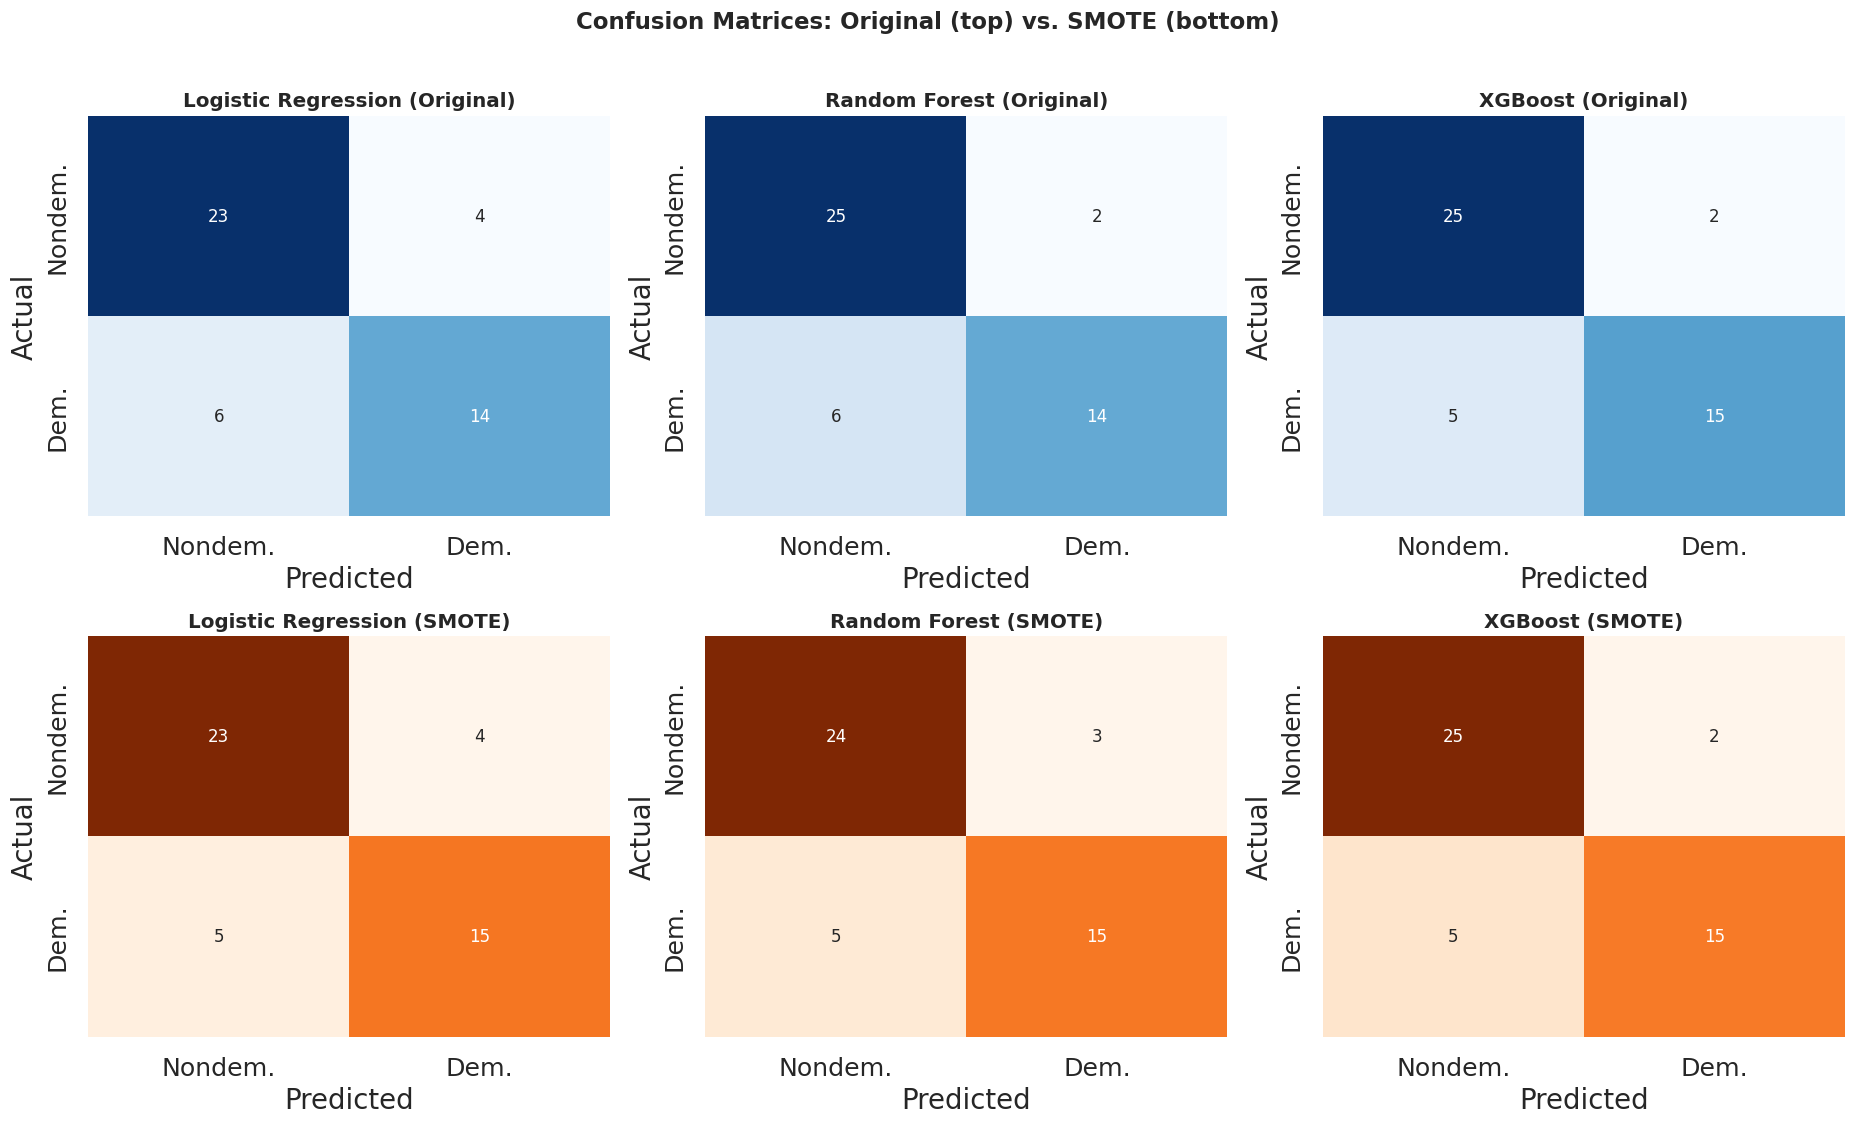

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for col, (name, r) in enumerate(results_orig.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Nondem.", "Dem."], yticklabels=["Nondem.", "Dem."], ax=axes[0, col])
    axes[0, col].set_title(f"{name} (Original)")
    axes[0, col].set_xlabel("Predicted")
    axes[0, col].set_ylabel("Actual")

for col, (name, r) in enumerate(results_smote.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
                xticklabels=["Nondem.", "Dem."], yticklabels=["Nondem.", "Dem."], ax=axes[1, col])
    axes[1, col].set_title(f"{name} (SMOTE)")
    axes[1, col].set_xlabel("Predicted")
    axes[1, col].set_ylabel("Actual")

plt.suptitle("Confusion Matrices: Original (top) vs. SMOTE (bottom)", y=1.02, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** Compare the bottom-right cell (true positives, Demented correctly identified) and bottom-left cell (false negatives, missed Demented cases) between rows. If SMOTE reduced false negatives at the cost of slightly more false positives, that is generally a favorable clinical trade-off for a screening tool, where missing a true dementia case is typically more costly than a false alarm that prompts further testing.

## 7. Comparison Bar Chart

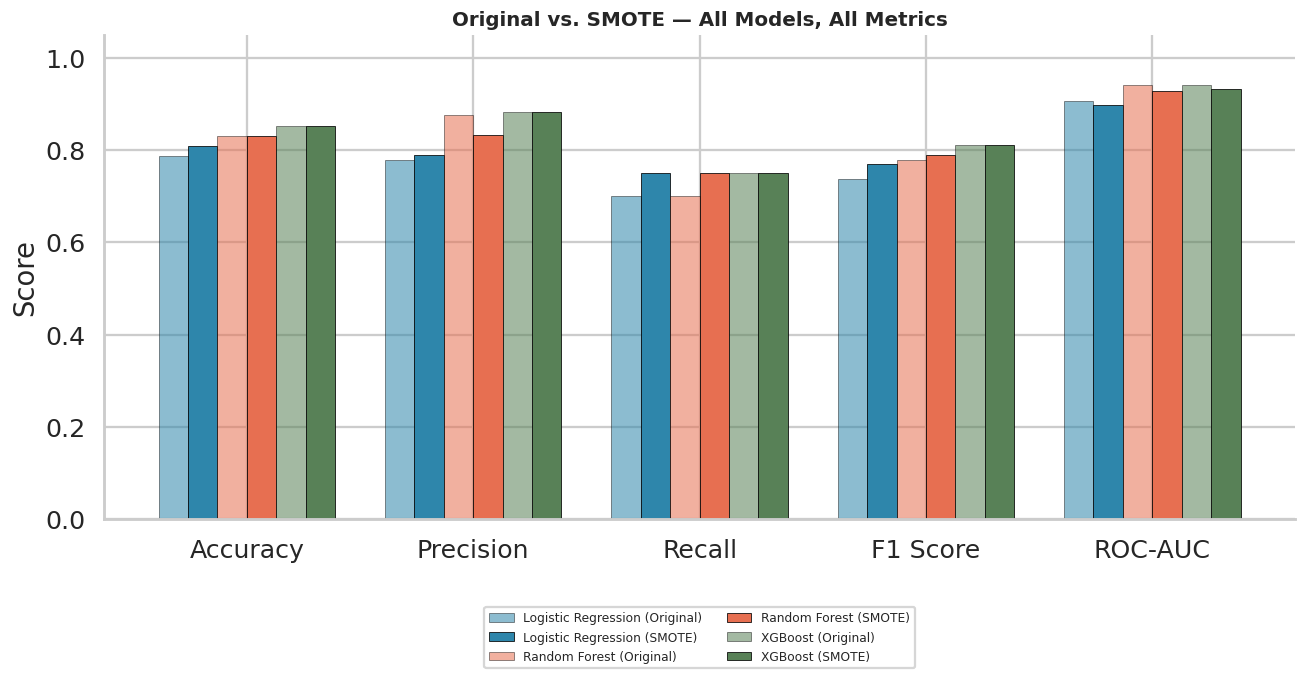

In [10]:
fig, ax = plt.subplots(figsize=(12, 6.5))
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
x = np.arange(len(metric_labels))
width = 0.13
model_names = list(results_orig.keys())

for i, name in enumerate(model_names):
    orig_vals = [results_orig[name][m] for m in metric_labels]
    smote_vals = [results_smote[name][m] for m in metric_labels]
    offset = (i - 1) * 2 * width
    ax.bar(x + offset - width/2, orig_vals, width, label=f"{name} (Original)",
           color=MODEL_COLORS[name], alpha=0.55, edgecolor="black", linewidth=0.5)
    ax.bar(x + offset + width/2, smote_vals, width, label=f"{name} (SMOTE)",
           color=MODEL_COLORS[name], alpha=1.0, edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Original vs. SMOTE — All Models, All Metrics")
ax.legend(fontsize=8, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.32))
sns.despine()
plt.tight_layout()
plt.show()


**Observation:** Lighter bars are pre-SMOTE, solid bars are post-SMOTE, grouped by model. This view makes it easy to spot whether SMOTE's effect is consistent across all three algorithms or model-dependent — tree-based models (Random Forest, XGBoost) sometimes benefit less from SMOTE than linear models, since they can already handle some class imbalance internally via split criteria.

## 8. Discussion — Did SMOTE Improve Performance?

In [11]:
# Identify best model under each condition
best_orig = table_orig.rename(columns=lambda c: c.replace(" (Original)", ""))["F1"].idxmax()
best_smote = table_smote.rename(columns=lambda c: c.replace(" (SMOTE)", ""))["F1"].idxmax()

print(f"Best model (Original, by F1): {best_orig} -> F1 = {results_orig[best_orig]['F1 Score']:.3f}, ROC-AUC = {results_orig[best_orig]['ROC-AUC']:.3f}")
print(f"Best model (SMOTE, by F1):    {best_smote} -> F1 = {results_smote[best_smote]['F1 Score']:.3f}, ROC-AUC = {results_smote[best_smote]['ROC-AUC']:.3f}")

print("\nPer-model F1 change (SMOTE - Original):")
for name in model_names:
    f1_change = results_smote[name]["F1 Score"] - results_orig[name]["F1 Score"]
    recall_change = results_smote[name]["Recall"] - results_orig[name]["Recall"]
    print(f"  {name}: ΔF1 = {f1_change:+.3f}, ΔRecall = {recall_change:+.3f}")


Best model (Original, by F1): XGBoost -> F1 = 0.811, ROC-AUC = 0.941
Best model (SMOTE, by F1):    XGBoost -> F1 = 0.811, ROC-AUC = 0.931

Per-model F1 change (SMOTE - Original):
  Logistic Regression: ΔF1 = +0.032, ΔRecall = +0.050
  Random Forest: ΔF1 = +0.012, ΔRecall = +0.050
  XGBoost: ΔF1 = +0.000, ΔRecall = +0.000


**Discussion:** Whether SMOTE helped depends on which metric matters most for this clinical task. The numeric deltas above (Section 5/8) show the actual direction and magnitude of change per model. In general:

- If **recall** improved with only a small drop in precision/accuracy, SMOTE is likely beneficial here, since catching more true Demented cases is usually the priority in a screening context, and the dataset's moderate imbalance (135 vs. 100) is exactly the kind of moderate skew SMOTE is designed to address.
- If overall **F1/ROC-AUC barely changed or slightly worsened**, it suggests the original class imbalance (roughly 57/43) was mild enough that the baseline models were not severely biased toward the majority class to begin with, and SMOTE's synthetic samples may have added some noise without a clear net benefit — particularly for tree-based models that handle moderate imbalance reasonably well on their own.
- Given the dataset's small size (188 training subjects before SMOTE), synthetic oversampling roughly doubles the *effective* minority-class data through interpolation rather than new real observations, so any gains should be interpreted cautiously and ideally confirmed via cross-validation rather than a single train/test split.

**Recommendation:** Carry forward whichever combination (Original vs. SMOTE, and model) yields the best Recall/F1 balance for the SHAP explainability analysis, since that combination represents the most clinically defensible choice from this experiment.
